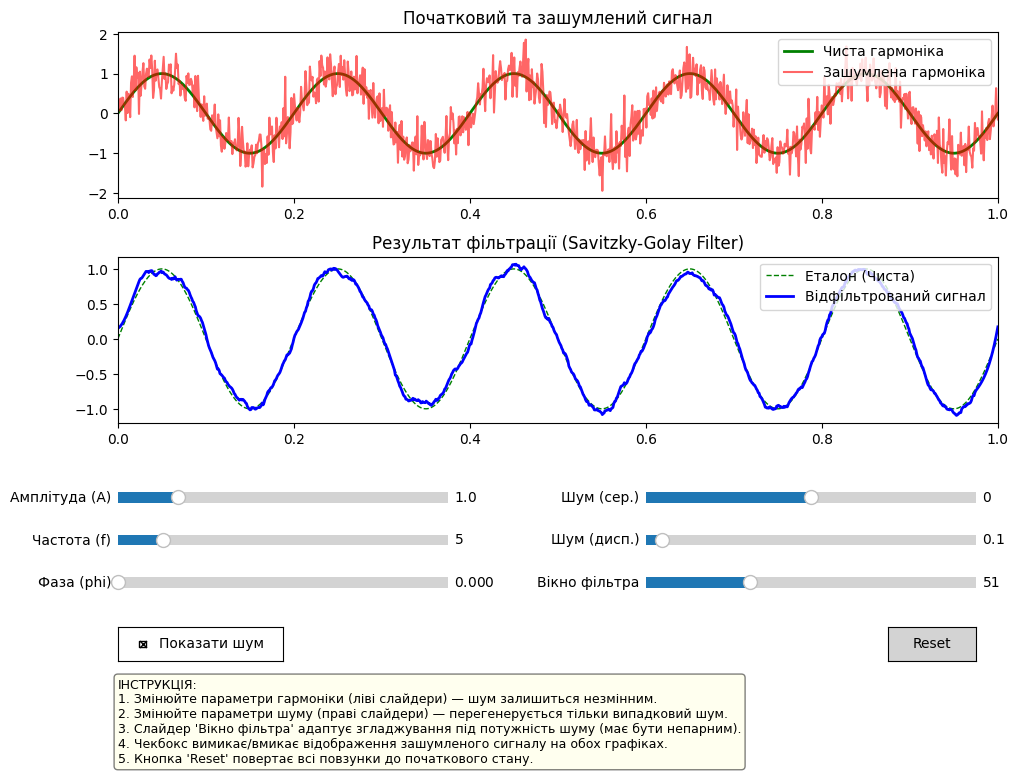

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button, CheckButtons
from scipy.signal import savgol_filter

# --- КРОК 1: ГЕНЕРАЦІЯ СИГНАЛУ ЗА ВИМОГАМИ ТЗ ---
def harmonic_with_noise(t, amplitude, frequency, phase, noise_mean, noise_covariance, show_noise):
    harmonic = amplitude * np.sin(2 * np.pi * frequency * t + phase)
    if show_noise:
        # Генеруємо базовий шум, якщо прапорець активовано
        noise = np.random.normal(noise_mean, np.sqrt(noise_covariance), len(t))
        return harmonic + noise
    else:
        return harmonic

# Параметри осі часу
t = np.linspace(0, 1, 1000)

# Початкові налаштування
init_amp = 1.0
init_freq = 5.0
init_phase = 0.0
init_noise_mean = 0.0
init_noise_cov = 0.1
init_window = 51

# Створення інтерфейсу (2 поля для графіків)
fig, (ax_orig, ax_filt) = plt.subplots(2, 1, figsize=(11, 8.5))
plt.subplots_adjust(left=0.1, bottom=0.42, hspace=0.35)

# Початкова генерація чистого сигналу та фіксованого шуму
pure_signal = amplitude = init_amp * np.sin(2 * np.pi * init_freq * t + init_phase)
current_noise = np.random.normal(init_noise_mean, np.sqrt(init_noise_cov), len(t))
noisy_signal = pure_signal + current_noise

# Відображення графіків
line_pure, = ax_orig.plot(t, pure_signal, label='Чиста гармоніка', color='green', lw=2)
line_noisy, = ax_orig.plot(t, noisy_signal, label='Зашумлена гармоніка', color='red', alpha=0.6)

# Результат фільтрації (Фільтр Савицького-Голая)
filtered_signal = savgol_filter(noisy_signal, init_window, 3)
line_filt_pure, = ax_filt.plot(t, pure_signal, label='Еталон (Чиста)', color='green', lw=1, linestyle='--')
line_filt, = ax_filt.plot(t, filtered_signal, label='Відфільтрований сигнал', color='blue', lw=2)

# Налаштування осей
ax_orig.legend(loc='upper right')
ax_filt.legend(loc='upper right')
ax_orig.set_title("Початковий та зашумлений сигнал")
ax_filt.set_title("Результат фільтрації (Savitzky-Golay Filter)")
ax_orig.set_xlim(0, 1)
ax_filt.set_xlim(0, 1)

# Текстова інструкція користувача прямо на вікні програми
instruction_text = (
    "ІНСТРУКЦІЯ:\n"
    "1. Змінюйте параметри гармоніки (ліві слайдери) — шум залишиться незмінним.\n"
    "2. Змінюйте параметри шуму (праві слайдери) — перегенерується тільки випадковий шум.\n"
    "3. Слайдер 'Вікно фільтра' адаптує згладжування під потужність шуму (має бути непарним).\n"
    "4. Чекбокс вимикає/вмикає відображення зашумленого сигналу на обох графіках.\n"
    "5. Кнопка 'Reset' повертає всі повзунки до початкового стану."
)
fig.text(0.1, 0.02, instruction_text, fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

# --- РОЗМІЩЕННЯ ЕЛЕМЕНТІВ КЕРУВАННЯ (Координати) ---
ax_amp = plt.axes([0.1, 0.32, 0.3, 0.025])
ax_freq = plt.axes([0.1, 0.27, 0.3, 0.025])
ax_phase = plt.axes([0.1, 0.22, 0.3, 0.025])

ax_n_mean = plt.axes([0.58, 0.32, 0.3, 0.025])
ax_n_cov = plt.axes([0.58, 0.27, 0.3, 0.025])
ax_window = plt.axes([0.58, 0.22, 0.3, 0.025]) # Новий слайдер параметрів фільтра

s_amp = Slider(ax_amp, 'Амплітуда (A)', 0.1, 5.0, valinit=init_amp)
s_freq = Slider(ax_freq, 'Частота (f)', 1.0, 30.0, valinit=init_freq)
s_phase = Slider(ax_phase, 'Фаза (phi)', 0.0, 2*np.pi, valinit=init_phase)

s_n_mean = Slider(ax_n_mean, 'Шум (сер.)', -2.0, 2.0, valinit=init_noise_mean)
s_n_cov = Slider(ax_n_cov, 'Шум (дисп.)', 0.0, 2.0, valinit=init_noise_cov)
s_window = Slider(ax_window, 'Вікно фільтра', 5, 151, valinit=init_window, valfmt='%d')

ax_check = plt.axes([0.1, 0.14, 0.15, 0.04])
check = CheckButtons(ax_check, ['Показати шум'], [True])

ax_reset = plt.axes([0.8, 0.14, 0.08, 0.04])
button = Button(ax_reset, 'Reset', color='lightgray')

# Трекер попередніх значень шуму для точкової фіксації змін за ТЗ
prev_noise_mean = init_noise_mean
prev_noise_cov = init_noise_cov

# --- ФУНКЦІЯ ІНТЕРАКТИВНОГО ОНОВЛЕННЯ ---
def update(val):
    global current_noise, prev_noise_mean, prev_noise_cov
    
    amp = s_amp.val
    freq = s_freq.val
    phase = s_phase.val
    n_mean = s_n_mean.val
    n_cov = s_n_cov.val
    show_n = check.get_status()[0]
    
    # Визначаємо розмір вікна фільтра (обов'язково непарне число)
    window = int(s_window.val)
    if window % 2 == 0:
        window += 1
        
    # Перевірка: якщо змінилися саме параметри шуму — перегенерувати масив шуму
    if n_mean != prev_noise_mean or n_cov != prev_noise_cov:
        current_noise = np.random.normal(n_mean, np.sqrt(n_cov), len(t))
        prev_noise_mean = n_mean
        prev_noise_cov = n_cov

    # Рахуємо чисту гармоніку
    pure_signal = amp * np.sin(2 * np.pi * freq * t + phase)
    line_pure.set_ydata(pure_signal)
    line_filt_pure.set_ydata(pure_signal)
    
    # Логіка чекбокса відображення шуму
    if show_n:
        noisy_signal = pure_signal + current_noise
        line_noisy.set_ydata(noisy_signal)
        line_noisy.set_visible(True)
        # Фільтруємо зашумлений сигнал
        line_filt.set_ydata(savgol_filter(noisy_signal, window, 3))
    else:
        line_noisy.set_visible(False)
        # Якщо відображення шуму вимкнено — фільтр працює з чистим сигналом
        line_filt.set_ydata(savgol_filter(pure_signal, window, 3))
        
    fig.canvas.draw_idle()

# Навішування подій зміни параметрів
s_amp.on_changed(update)
s_freq.on_changed(update)
s_phase.on_changed(update)
s_n_mean.on_changed(update)
s_n_cov.on_changed(update)
s_window.on_changed(update)
check.on_clicked(update)

# Функція скидання параметрів
def reset(event):
    s_amp.reset()
    s_freq.reset()
    s_phase.reset()
    s_n_mean.reset()
    s_n_cov.reset()
    s_window.reset()
    # Якщо стан чекбокса був змінений на False — повертаємо True
    if not check.get_status()[0]:
        check.set_active(0)
        
button.on_clicked(reset)

plt.show()